<a href="https://colab.research.google.com/github/santhosh-kumar1928/santhoshkumar-codeboosters-2026/blob/main/day3/day3_miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
API_key='932193c3c723ae47f8e976e8f17e7f5a'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES=['Mumbai','Delhi','Bangalore','Coimbatore ','Hyderabad','kolkata','pollachi','jaipur']
print(f'API configured for{len(CITIES)} cities')
print(f'cities:{CITIES}')
print('dc28636fe03c10e9a97bf20acfa3813c')

API configured for8 cities
cities:['Mumbai', 'Delhi', 'Bangalore', 'Coimbatore ', 'Hyderabad', 'kolkata', 'pollachi', 'jaipur']
dc28636fe03c10e9a97bf20acfa3813c


In [18]:
import requests

def fetch_weather(city, api_key):

  params = {
      'q' : city,
      'appid' :api_key,
      'units': 'metric'
  }
  try:
    response = requests.get(BASE_URL, params=params, timeout = 10)

    if response.status_code == 200:
      data = response.json()

      return{
          'city':city,
          'temperature':round(data['main']['temp'],1),
          'feels_like':round(data['main']['feels_like'],1),
          'wind_speed':data['wind']['speed'],
          'condition': data['weather'][0]['main'].title(),
          'visibility':data.get('visibility',0)
      }
    else:
        print(f'ERROR {response.status_code}) for {city} : {response.json().get("message")}')
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
  return None # Explicitly return None on error


print("CALLING weather API..")
weather_records = []

for city in CITIES:
  print(f'Fetching:{city}...', end ='')
  record = fetch_weather(city, API_key)
  if record:
    weather_records.append(record)
    print(f'{record["temperature"]}C, {record["condition"]}')
  else:
    print('FAILED')
print(f'\nSuccessfully fetched:{len(weather_records)}/{len(CITIES)} cities')

CALLING weather API..
Fetching:Mumbai...34.0C, Haze
Fetching:Delhi...44.0C, Clear
Fetching:Bangalore...29.8C, Clouds
Fetching:Coimbatore ...33.9C, Clouds
Fetching:Hyderabad...31.2C, Clouds
Fetching:kolkata...32.0C, Haze
Fetching:pollachi...33.8C, Clouds
Fetching:jaipur...42.6C, Haze

Successfully fetched:8/8 cities


In [ ]:
weather_df=pd.Dataframe(weather_records)
print(Weather_df.to_string(index=False))
print(f'\nShape:')

CALLING weather API..
Fetching:Mumbai...33.0C, Haze
Fetching:Delhi...44.0C, Clear
Fetching:Bangalore...29.7C, Clouds
Fetching:Coimbatore ...33.9C, Clouds
Fetching:Hyderabad...31.2C, Clouds
Fetching:kolkata...32.0C, Haze
Fetching:pollachi...33.8C, Clouds
Fetching:jaipur...42.6C, Haze

Successfully fetched:8/8 cities


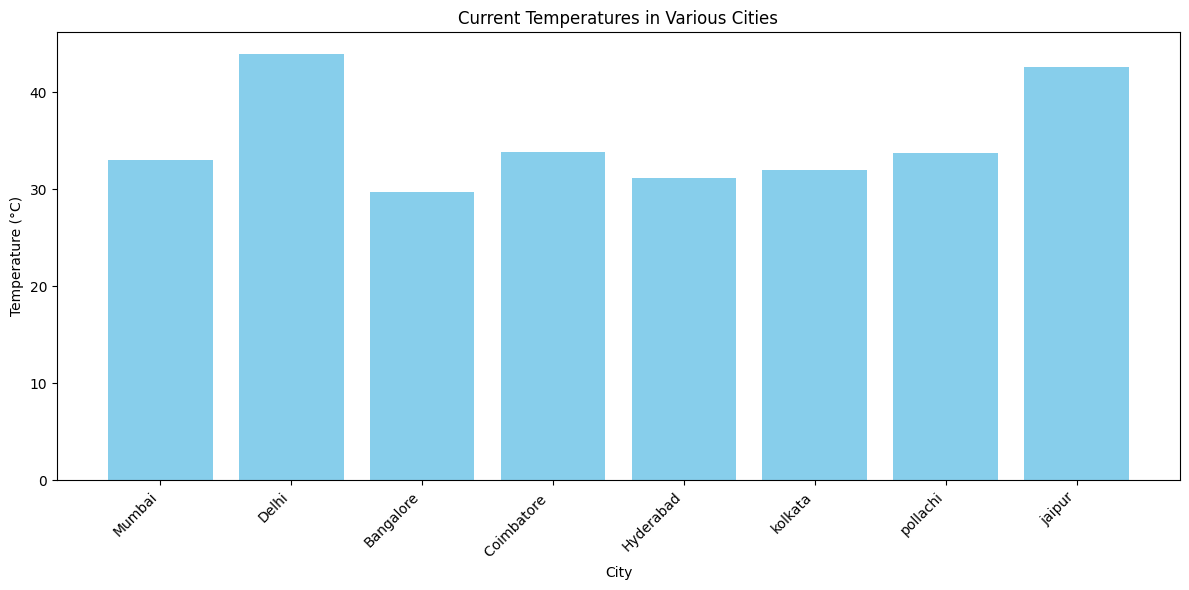


Weather Data Table:
          city  temperature  feels_like  humidity  pressure  wind_speed  \
0       Mumbai         33.0        38.8        58      1009        4.63   
1        Delhi         44.0        41.1        10       999        5.14   
2    Bangalore         29.7        31.4        55      1010        6.71   
3  Coimbatore          33.9        38.8        52      1008        6.17   
4    Hyderabad         31.2        32.6        48      1010        7.20   
5      kolkata         32.0        38.9        66      1001        3.60   
6     pollachi         33.8        37.0        47      1008        8.11   
7       jaipur         42.6        40.9        14      1001        5.66   

  condition  visibility  
0      Haze        7000  
1     Clear        7000  
2    Clouds        8000  
3    Clouds        7000  
4    Clouds        6000  
5      Haze        5000  
6    Clouds       10000  
7      Haze        5000  


In [21]:
import requests
import matplotlib.pyplot as plt
import pandas as pd

def fetch_weather(city, api_key):

  params = {
      'q' : city,
      'appid' :api_key,
      'units': 'metric'
  }
  try:
    response = requests.get(BASE_URL, params=params, timeout = 10)

    if response.status_code == 200:
      data = response.json()

      return{
          'city':city,
          'temperature':round(data['main']['temp'],1),
          'feels_like':round(data['main']['feels_like'],1),
          'humidity':data['main']['humidity'], # Added humidity
          'pressure':data['main']['pressure'], # Added pressure
          'wind_speed':data['wind']['speed'],
          'condition': data['weather'][0]['main'].title(),
          'visibility':data.get('visibility',0)
      }
    else:
        print(f'ERROR {response.status_code}) for {city} : {response.json().get("message")}')
  except requests.exceptions.ConnectionError:
    print(f'CONNECTION ERROR for {city} - check internet connection')
  return None # Explicitly return None on error


print("CALLING weather API..")
weather_records = []

for city in CITIES:
  print(f'Fetching:{city}...', end ='')
  record = fetch_weather(city, API_key)
  if record:
    weather_records.append(record)
    print(f'{record["temperature"]}C, {record["condition"]}')
  else:
    print('FAILED')
print(f'\nSuccessfully fetched:{len(weather_records)}/{len(CITIES)} cities')

cities_plot = [record['city'] for record in weather_records]
temperatures_plot = [record['temperature'] for record in weather_records]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(cities_plot, temperatures_plot, color='skyblue')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.title('Current Temperatures in Various Cities')
plt.xticks(rotation=45, ha='right') # Rotate city names for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Display data using pandas
df_weather = pd.DataFrame(weather_records)
print("\nWeather Data Table:")
print(df_weather[['city', 'temperature', 'feels_like', 'humidity', 'pressure', 'wind_speed', 'condition', 'visibility']])